# UNSW-NB15 Preprocessing Pipeline
A clean, modular pipeline for loading, deduplicating, and preprocessing the UNSW-NB15 intrusion detection dataset for **multiclass classification** using `attack_cat` as the target.


## 1. Imports

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler



## 2. Configuration

In [6]:
TRAIN_PATH = "UNSW_NB15_training-set.csv"
TEST_PATH  = "UNSW_NB15_testing-set.csv"

# ID / address columns — dropped BEFORE deduplication so that
# unique IP/port values do not prevent detection of true feature-level duplicates
ID_COLS = ["id", "srcip", "sport", "dstip", "dsport"]

# Binary label — not needed for multiclass (we use attack_cat)
BINARY_LABEL = "label"

# Categorical columns to be One-Hot Encoded
CAT_COLS = ["proto", "service", "state"]

# Highly correlated columns to drop (identified during EDA with threshold > 0.95).
# Hardcoded from EDA results — DO NOT recompute dynamically on the feature matrix,
# because removing label/attack_cat before computing correlation changes the
# correlation structure and causes extra columns to be incorrectly dropped,
# reducing the final feature count below 194.
CORR_COLS = [
    "sloss", "dloss", "dpkts", "dwin", "ltime",
    "ct_srv_dst", "ct_src_dport_ltm", "ct_dst_src_ltm"
]

# Skewed numerical columns — log1p transform applied
LOG1P_COLS = [
    "dur", "sbytes", "dbytes", "sload", "dload", "spkts",
    "stcpb", "dtcpb", "smeansz", "dmeansz", "sjit", "djit"
]

# Binary-valued columns that must stay in {0, 1}
BINARY_COLS = ["is_sm_ips_ports", "is_ftp_login", "ct_flw_http_mthd"]

# Expected feature count after full preprocessing
# 43 features − 8 corr = 35 → 32 numerical + 3 cat
# OHE: proto(133) + service(13) + state(16) = 162
# Total: 32 + 162 = 194
EXPECTED_FEATURES = 194


## 3. Data Loading

In [8]:
def load_unsw(train_path: str = TRAIN_PATH, test_path: str = TEST_PATH):
    """Load UNSW-NB15 train/test CSVs and return raw DataFrames."""
    train_df = pd.read_csv(train_path)
    test_df  = pd.read_csv(test_path)

    print(f"Train shape : {train_df.shape}")
    print(f"Test  shape : {test_df.shape}")
    return train_df, test_df

train_df, test_df = load_unsw()


Train shape : (175341, 45)
Test  shape : (82332, 45)


## 4. Drop ID Columns and Binary Label

`id`, `srcip`, `sport`, `dstip`, `dsport` are address/identifier columns dropped **before** deduplication — unique IP addresses would otherwise prevent detection of true feature-level duplicates. The binary `label` column is also dropped here since `attack_cat` is our multiclass target.


In [10]:
def drop_ids(df: pd.DataFrame) -> pd.DataFrame:
    """Drop ID/address columns and binary label. Must run BEFORE deduplication."""
    cols_to_drop = [c for c in ID_COLS + [BINARY_LABEL] if c in df.columns]
    df = df.drop(columns=cols_to_drop)
    print(f"Dropped : {cols_to_drop}")
    print(f"Shape   : {df.shape}")
    return df

train_df = drop_ids(train_df)
test_df  = drop_ids(test_df)


Dropped : ['id', 'label']
Shape   : (175341, 43)
Dropped : ['id', 'label']
Shape   : (82332, 43)


## 5. Remove Duplicates

In [12]:
def remove_duplicates(train_df: pd.DataFrame, test_df: pd.DataFrame):
    """Drop exact duplicate rows from train and test sets."""    
    train_before = len(train_df)
    test_before  = len(test_df)

    train_df = train_df.drop_duplicates().reset_index(drop=True)
    test_df  = test_df.drop_duplicates().reset_index(drop=True)

    print(f"Train — before: {train_before:,}  after: {len(train_df):,}  "
          f"dropped: {train_before - len(train_df):,}")
    print(f"Test  — before: {test_before:,}   after: {len(test_df):,}   "
          f"dropped: {test_before  - len(test_df):,}")
    return train_df, test_df

train_df, test_df = remove_duplicates(train_df, test_df)


Train — before: 175,341  after: 107,740  dropped: 67,601
Test  — before: 82,332   after: 55,945   dropped: 26,387


## 6. Label Engineering

Extract `attack_cat` as the multiclass target. Strip whitespace, then apply `LabelEncoder` fit on train only. Label encoding is applied **after** all feature encoding steps.


In [14]:
def label_data(train_df: pd.DataFrame, test_df: pd.DataFrame):
    """
    Extract attack_cat as target and apply LabelEncoder.
    Returns X_train, y_train, X_test, y_test, fitted LabelEncoder.
    """
    train_df = train_df.copy()
    test_df  = test_df.copy()

    # Normalise whitespace in class names
    train_df["attack_cat"] = train_df["attack_cat"].astype(str).str.strip()
    test_df["attack_cat"]  = test_df["attack_cat"].astype(str).str.strip()

    # Fit LabelEncoder on train classes only
    le = preprocessing.LabelEncoder()
    y_train = le.fit_transform(train_df["attack_cat"])
    y_test  = le.transform(test_df["attack_cat"])

    print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

    X_train = train_df.drop(columns=["attack_cat"])
    X_test  = test_df.drop(columns=["attack_cat"])

    y_train = pd.Series(y_train, name="attack_cat", index=X_train.index)
    y_test  = pd.Series(y_test,  name="attack_cat", index=X_test.index)

    return X_train, y_train, X_test, y_test, le

X_train, y_train, X_test, y_test, le = label_data(train_df, test_df)

print(f"\nX_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}  |  y_test: {y_test.shape}")


Label mapping: {'Analysis': 0, 'Backdoor': 1, 'DoS': 2, 'Exploits': 3, 'Fuzzers': 4, 'Generic': 5, 'Normal': 6, 'Reconnaissance': 7, 'Shellcode': 8, 'Worms': 9}

X_train: (107740, 42)  |  X_test: (55945, 42)
y_train: (107740,)  |  y_test: (55945,)


## 7. Preprocessing Pipeline

In [16]:
def drop_correlated(X_train: pd.DataFrame, X_test: pd.DataFrame,
                    corr_cols: list = CORR_COLS):
    """
    Drop highly correlated features identified during EDA (threshold > 0.95).
    Uses a hardcoded list from EDA — NOT recomputed dynamically — because
    computing correlation after removing the target changes the correlation
    structure and causes extra columns to exceed the threshold, resulting in
    fewer than 194 final features.
    """
    cols = [c for c in corr_cols if c in X_train.columns]
    X_train = X_train.drop(columns=cols)
    X_test  = X_test.drop(columns=cols)
    print(f"Dropped correlated columns ({len(cols)}): {cols}")
    print(f"Shape → train: {X_train.shape}  test: {X_test.shape}")
    return X_train, X_test


In [17]:
def apply_log1p(X_train: pd.DataFrame, X_test: pd.DataFrame,
                log1p_cols: list = LOG1P_COLS):
    """Apply log1p transform to skewed numerical columns in-place."""    
    applied = []
    for col in log1p_cols:
        if col in X_train.columns:
            X_train[col] = np.log1p(X_train[col])
            X_test[col]  = np.log1p(X_test[col])
            applied.append(col)
    print(f"log1p applied to ({len(applied)}): {applied}")
    return X_train, X_test


In [18]:
def clean_data(df: pd.DataFrame, mode_dict: dict,
               binary_cols: list = BINARY_COLS,
               cat_cols: list = CAT_COLS) -> pd.DataFrame:
    """Fill nulls with train mode, replace bad placeholders, clip binary columns."""    
    for col in df.columns:
        val = mode_dict.get(col, 0)
        df[col] = df[col].fillna(val)
        if df[col].dtype == object:
            df[col] = df[col].replace(' ', val)
            df[col] = df[col].apply(lambda x: 'None' if str(x).strip() == '-' else x)
        if col in binary_cols:
            df[col] = np.where(df[col] > 1, val, df[col])
    # Fix any numeric column mistakenly read as object
    bad = [c for c in df.select_dtypes(exclude=np.number).columns
           if c not in cat_cols]
    for col in bad:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(mode_dict.get(col, 0))
    return df


In [19]:
def build_preprocessor(X_train: pd.DataFrame, X_test: pd.DataFrame, cat_cols: list = CAT_COLS):
    """
    Fit StandardScaler on numerical columns and OneHotEncoder with EXPLICIT categories
    to ensure exactly 194 features (32 numerical + 162 categorical).
    """
    num_cols = [c for c in X_train.columns if c not in cat_cols]

    # 1. Fit Scaler on numerical columns
    scaler = StandardScaler()
    scaler.fit(X_train[num_cols])

    # 2. Define the exact lists to reach 162 OHE features (133 + 13 + 16)
    proto_list = [
        '3pc', 'a/n', 'aes-sp3-d', 'any', 'argus', 'aris', 'arp', 'ax.25', 'bbn-vcc', 'bna', 'br-sat-mon',
        'cbt', 'cftp', 'chaos', 'compaq-peer', 'cphb', 'cpnx', 'crtp', 'crudp', 'dcn', 'dccp', 'ddp', 'ddx', 
        'dgp', 'egp', 'eigrp', 'emcon', 'encap', 'etherip', 'fc', 'fire', 'ggp', 'gmtp', 'gre', 'hmp', 
        'hopopt', 'iatp', 'ib', 'icmp', 'idpr', 'idpr-cmtp', 'idrp', 'ifmp', 'igmp', 'igp', 'il', 'ip', 
        'ip-as0', 'ip-comp', 'ip-cv', 'ip-pcp', 'ipcomp', 'ipencap', 'ipip', 'iplt', 'ippc', 'ipv6', 
        'ipv6-frag', 'ipv6-no', 'ipv6-opts', 'ipv6-route', 'ipx-n-ip', 'irtp', 'isis', 'iso-ip', 'iso-tp4', 
        'kryptolan', 'l2tp', 'larp', 'leaf-1', 'leaf-2', 'merit-inp', 'mfe-nsp', 'mhrp', 'micp', 'mobile', 
        'mtp', 'mux', 'narp', 'netblt', 'nsfnet-igp', 'nvp', 'ospf', 'pgm', 'pim', 'pipe', 'pnni', 'prm', 
        'ptp', 'pup', 'pvp', 'qnx', 'rdp', 'rtp', 'rtcp', 'rvd', 'sat-expak', 'sat-mon', 'scc-sp', 'scps', 
        'sctp', 'sdrp', 'secure-vmtp', 'sep', 'skip', 'sm', 'smp', 'snp', 'sprite-rpc', 'sps', 'srp', 
        'st2', 'stp', 'sun-nd', 'swipe', 'tcf', 'tcp', 'tlsp', 'tp++', 'trunk-1', 'trunk-2', 'ttp', 'udp', 
        'unas', 'vmtp', 'vocaltec', 'vrrp', 'wes', 'wsn', 'xnet', 'xns-idp', 'xtp', 'zero'
    ] # 133 Protocols
    
    service_list = ['-', 'dhcp', 'dns', 'ftp', 'ftp-data', 'http', 'irc', 'pop3', 'radius', 'smtp', 'snmp', 'ssh', 'ssl'] # 13 Services
    
    state_list = ['ACC', 'CLO', 'CON', 'ECO', 'ECR', 'FIN', 'INT', 'MAS', 'PAR', 'REQ', 'RST', 'TST', 'TXU', 'URH', 'URN', 'no'] # 16 States

    # 3. Fit OneHotEncoder using these fixed category lists
    ohe = OneHotEncoder(categories=[proto_list, service_list, state_list], 
                         handle_unknown="ignore", sparse_output=False)
    ohe.fit(X_train[cat_cols])

    ohe_feature_names = ohe.get_feature_names_out(cat_cols).tolist()

    print(f"Numerical columns  : {len(num_cols)}")
    print(f"Total OHE features : {len(ohe_feature_names)} (133 proto + 13 service + 16 state)")
    print(f"Final Feature Count: {len(num_cols) + len(ohe_feature_names)}")

    return scaler, ohe, num_cols, ohe_feature_names

In [20]:
def apply_preprocessor(df: pd.DataFrame, scaler, ohe,
                        num_cols: list, ohe_feature_names: list,
                        cat_cols: list = CAT_COLS) -> pd.DataFrame:
    """
    Apply fitted scaler and OHE to a DataFrame.
    Numerical columns come first, then OHE-expanded categorical columns.
    """
    df = df.reset_index(drop=True)

    scaled  = pd.DataFrame(scaler.transform(df[num_cols]), columns=num_cols)
    encoded = pd.DataFrame(ohe.transform(df[cat_cols]),    columns=ohe_feature_names)

    return pd.concat([scaled, encoded], axis=1)


In [21]:
def run_pipeline(X_train: pd.DataFrame, X_test: pd.DataFrame):
    """
    End-to-end feature preprocessing.
    """
    # 1. Drop correlated features
    X_train, X_test = drop_correlated(X_train, X_test)

    # 2. log1p transform
    X_train, X_test = apply_log1p(X_train, X_test)

    # 3. Clean — compute mode from train only
    mode_dict = X_train.mode().iloc[0].to_dict()
    X_train = clean_data(X_train.copy(), mode_dict)
    X_test  = clean_data(X_test.copy(),  mode_dict)

    # 4 & 5. Fit scaler + OHE
    # CHANGE THIS LINE BELOW: Added X_test as an argument
    scaler, ohe, num_cols, ohe_feature_names = build_preprocessor(X_train, X_test)

    # 6. Apply to train and test
    X_train_p = apply_preprocessor(X_train, scaler, ohe, num_cols, ohe_feature_names)
    X_test_p  = apply_preprocessor(X_test,  scaler, ohe, num_cols, ohe_feature_names)

    # Sanity checks
    assert not X_train_p.isnull().any().any(), "NaNs in X_train_p!"
    assert not X_test_p.isnull().any().any(),  "NaNs in X_test_p!"
    assert list(X_train_p.columns) == list(X_test_p.columns), "Column mismatch!"
    
    # This assertion should now pass if your files contain the expected categories
    assert X_train_p.shape[1] == EXPECTED_FEATURES, (
        f"Feature count mismatch: got {X_train_p.shape[1]}, expected {EXPECTED_FEATURES}"
    )

    print(f"\n✓ X_train_p: {X_train_p.shape}  |  X_test_p: {X_test_p.shape}")

    return X_train_p, X_test_p, scaler, ohe, mode_dict, num_cols, ohe_feature_names

# Execute the pipeline
X_train_p, X_test_p, scaler, ohe, mode_dict, num_cols, ohe_feature_names = run_pipeline(X_train, X_test)

Dropped correlated columns (7): ['sloss', 'dloss', 'dpkts', 'dwin', 'ct_srv_dst', 'ct_src_dport_ltm', 'ct_dst_src_ltm']
Shape → train: (107740, 35)  test: (55945, 35)
log1p applied to (10): ['dur', 'sbytes', 'dbytes', 'sload', 'dload', 'spkts', 'stcpb', 'dtcpb', 'sjit', 'djit']
Numerical columns  : 32
Total OHE features : 162 (133 proto + 13 service + 16 state)
Final Feature Count: 194

✓ X_train_p: (107740, 194)  |  X_test_p: (55945, 194)


## 8. EDA

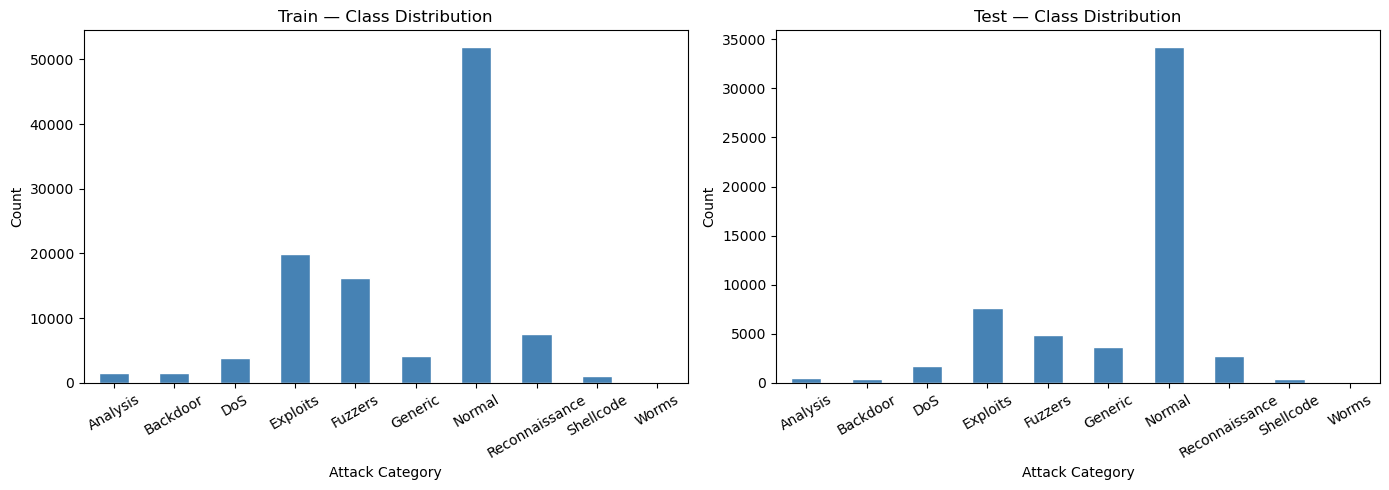

Train class counts:
attack_cat
Normal            51890
Exploits          19844
Fuzzers           16150
Reconnaissance     7522
Generic            4181
DoS                3806
Analysis           1594
Backdoor           1535
Shellcode          1091
Worms               127
Name: count, dtype: int64

Test class counts:
attack_cat
Normal            34206
Exploits           7609
Fuzzers            4838
Generic            3657
Reconnaissance     2703
DoS                1718
Analysis            446
Shellcode           378
Backdoor            346
Worms                44
Name: count, dtype: int64


In [23]:
# --- 8a. Class distribution ---
label_names = dict(enumerate(le.classes_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (y, title) in zip(axes, [(y_train, "Train"), (y_test, "Test")]):
    counts = y.value_counts().sort_index()
    counts.index = [label_names[i] for i in counts.index]
    counts.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(f"{title} — Class Distribution")
    ax.set_xlabel("Attack Category")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

print("Train class counts:")
print(y_train.map(label_names).value_counts())
print("\nTest class counts:")
print(y_test.map(label_names).value_counts())


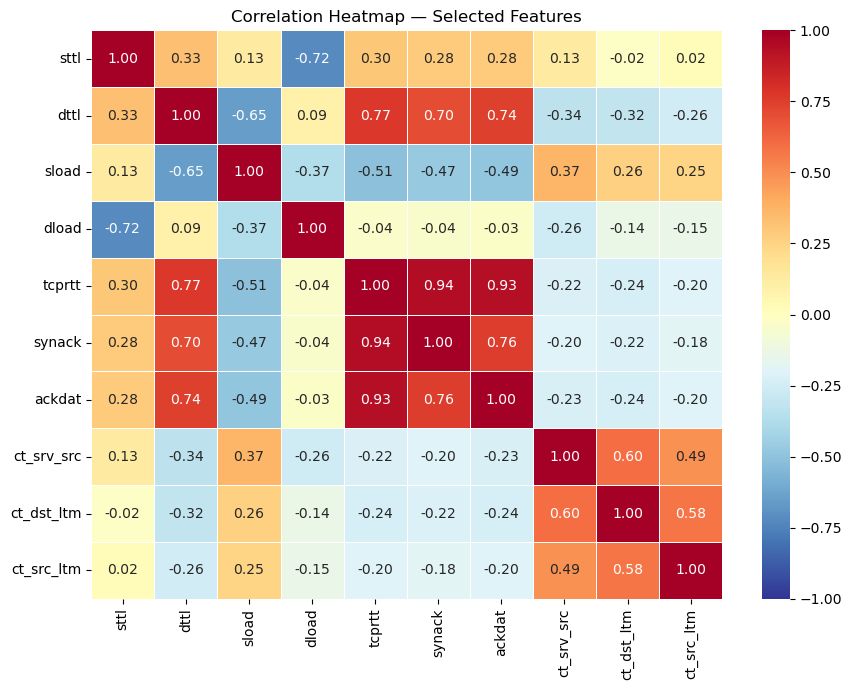

In [24]:
# --- 8b. Correlation heatmap (selected numerical features) ---
CORR_FEATURES = [
    "sttl", "dttl", "sload", "dload", "tcprtt",
    "synack", "ackdat", "ct_srv_src", "ct_dst_ltm", "ct_src_ltm",
]

resolved = [f for f in CORR_FEATURES if f in X_train_p.columns]

corr = X_train_p[resolved].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, cmap="RdYlBu_r", vmin=-1, vmax=1,
            annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap — Selected Features")
plt.tight_layout()
plt.show()


## 9. Save Artifacts

In [41]:
import pickle
import pandas as pd

# Folder containing the saved pickle files
file_path = "final_ipynb/"

# ==============================
# Load Training Data
# ==============================
X_train_p, y_train = pickle.load(
    open(file_path + "final_train.pkl", "rb")
)

train_preprocessed = X_train_p.copy()
train_preprocessed["attack_cat"] = y_train

# ==============================
# Load Testing Data
# ==============================
X_test_p, y_test = pickle.load(
    open(file_path + "final_test.pkl", "rb")
)

test_preprocessed = X_test_p.copy()
test_preprocessed["attack_cat"] = y_test

# ==============================
# Save as CSV
# ==============================
train_preprocessed.to_csv("train_preprocessed.csv", index=False)
test_preprocessed.to_csv("test_preprocessed.csv", index=False)

# ==============================
# Print Information
# ==============================
print("CSV files saved successfully!")
print(f"Train Shape: {train_preprocessed.shape}")
print(f"Test Shape:  {test_preprocessed.shape}")

# ==============================
# Download Files (Google Colab)
# ==============================
try:
    from google.colab import files

    files.download("train_preprocessed.csv")
    files.download("test_preprocessed.csv")

except:
    print("\nIf you are not using Google Colab,")
    print("the CSV files are saved in your current working folder.")

CSV files saved successfully!
Train Shape: (107740, 195)
Test Shape:  (55945, 195)

If you are not using Google Colab,
the CSV files are saved in your current working folder.


In [43]:
import os

print(os.getcwd())

C:\Users\MSI
